Resumen: 
- Implementacion:
    - Training: noiseless, noisy y real
    - Evaluation: noiseless y noisy
- Simulación via qiskit_aer (en GPUs)
- Optimicación pytorch para evaluacion en multiples GPUs

Embedding:
- Angle embedding
- Batch parallelization via qiskit_aer pubs. Fake pubs in EstimatorQNN, Real pubs without EstimatorQNN.

## Implementation (statevector simulation)

In [5]:
#--- INSTALATION INSTRUCTIONS ---#

# For linux 64-bit systems,
#uname -a

# Conda quick installation
#mkdir -p ~/miniconda3
#wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda3/miniconda.sh
#bash ~/miniconda3/miniconda.sh -b -u -p ~/miniconda3
#rm ~/miniconda3/miniconda.sh

# Create enviroment with conda
#conda create -n myenv python=3.10
#conda activate myenv
#pip install qiskit qiskit-machine-learning 'qiskit-machine-learning[sparse]' qiskit_aer qiskit-aer-gpu qiskit_algorithms torch matplotlib pylatexenc ipykernelc
# IMPORTANT: Make sure you are on 3.10
# May need to restart the kernel after instalation

#--- Imports ---#
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import random_statevector, Statevector, SparsePauliOp
from qiskit.circuit.library import real_amplitudes, efficient_su2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit import qpy

from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient, SPSAEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as EstimatorV2_sim, SamplerV2 as SamplerV2_sim
from qiskit_aer.quantum_info import AerStatevector
from qiskit_aer.library import SaveProbabilities

from qiskit_ibm_runtime import EstimatorV2 as EstimatorV2_rh, QiskitRuntimeService, Session

from qiskit_algorithms.gradients import ReverseEstimatorGradient

import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import os
import signal
import datetime as dt
import pickle
import yaml
import argparse

In [6]:
# #- Parameter management for python scripts -#

# if __name__ == "__main__":
#     parser = argparse.ArgumentParser(
#         description="Fully Quantum GAN"
#     )
#     parser.add_argument("-c", "--config_path", required=True, type=str)
#     args = parser.parse_args()

#     configuration_file_path = args.config_path

In [ ]:
#- Load configuration file -#

configuration_file_path = "../data/test/qgan_TorchConnector_ang-q3-noiseless-CPU-SPSA-randomTrue-seed0/config.yaml"
config_path = os.path.dirname(configuration_file_path) + "/"

# Load config file
def load_config_file(filename):
    with open(filename, "r") as file:
        config = yaml.safe_load(file)

    return config


config = load_config_file(configuration_file_path)


In [8]:
#- Create backend -#

# Get shots from precision
def get_shots(precision):
    if np.isclose(precision, 0, atol=1e-8):
        return None
    else:
        return int(1/(precision**2))

# Get simulation options
def get_sim_options(config, execution_type, precision):
    sim_backend_options = config['backend_options']['sim_backend_options']
    method_key = 'noisy_sim_method' if execution_type in ["noisy", "real"] else 'noiseless_sim_method'

    sim_options = {
        'method': sim_backend_options[method_key],
        'precision': config['backend_options']['data_type'],
        'seed_simulator': config['implementation_options']['seed'],
        'shots': get_shots(precision),
    }

    if config['implementation_options']['device'] == "GPU":
        sim_options['device'] = 'GPU'
        sim_options.update(config['gpu_device_options'])

    return sim_options


# Load backend options
real_backend_options = config['backend_options']['real_backend_options']
estimator_options = real_backend_options.get('real_estimator_options', {})
training_precision = config['backend_options']['training_precision']
if config['implementation_options']['execution_type'] == "real" and 'default_precision' in estimator_options:
    training_precision = estimator_options['default_precision']

eval_precision = config['eval_options']['eval_precision']
sim_options = get_sim_options(
    config,
    config['implementation_options']['execution_type'],
    training_precision,
)
eval_options = get_sim_options(
    config,
    config['eval_options']['eval_execution_type'],
    eval_precision,
)




# # Save account
# QiskitRuntimeService.save_account(
#     token="",
#     instance="crn:v1:bluemix:public:quantum-computing:eu-de:a/cb804b30dfcb48b890393bfd6e41e9c2:4cb40c64-a531-4c13-b39c-e04c31185259::",
#     set_as_default = True,
#     overwrite=True
# )


# Save backend file
def create_backend_file(backend, filename):
    backend_dict = {
        'timestamp': dt.datetime.now(dt.timezone.utc),
        'configuration': backend.configuration(),
        'properties': backend.properties(),
        'target': backend.target,
        'options': backend.options,
        'noise_model': None if config['implementation_options']['execution_type'] == "noiseless" else backend.options.noise_model
    }

    with open(filename, "wb") as f:
        pickle.dump(backend_dict, f)

    print("Backend file created.")


# Load backend file (just for simulation)
def load_backend_file(filename):
    if config['data_management']['reset_backend'] or not os.path.exists(filename):
        # Get real backend info
        if config['implementation_options']['execution_type'] == "noisy" and config['data_management']['reset_backend']:
            service = QiskitRuntimeService(channel=real_backend_options['channel'])
            real_backend = service.backend(real_backend_options['name']) #backend = service.least_busy(min_num_qubits=30)
            backend = AerSimulator.from_backend(real_backend, **sim_options) # Get current backend state
        else:
            backend = AerSimulator(**sim_options)

        create_backend_file(backend, filename)

    with open(filename, "rb") as f:
            backend_dict = pickle.load(f)

    return backend_dict


# Create backend
if config['implementation_options']['execution_type'] == "real":
    # Get real backend
    service = QiskitRuntimeService(channel=real_backend_options['channel'])
    backend = service.backend(real_backend_options['name']) #backend = service.least_busy(min_num_qubits=30)

    # Save backend info
    create_backend_file(backend, config_path + "backend.pkl")

    # Create session
    session = Session(backend=backend)

    # Create estimator
    estimator = EstimatorV2_rh(mode=session, options=estimator_options)

else:
    # Load backend configuration
    backend_dict = load_backend_file(config_path + "backend.pkl")

    # Create backend
    backend = AerSimulator(
        configuration=backend_dict['configuration'],
        properties=backend_dict['properties'],
        target=backend_dict['target'],
        **backend_dict['options']
    )

    # Create Estimator for simulation
    estimator = EstimatorV2_sim(
        options = {
            "default_precision": training_precision,
            "backend_options": backend.options,
        })


# Transpilation method
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    seed_transpiler=config['implementation_options']['seed']
)



# Backend, estimator and pm for noiseless evaluation (do not need to execute evaluation in a nosiy environment)
eval_backend = AerSimulator(**eval_options)
eval_estimator = EstimatorV2_sim(options = {"default_precision": eval_precision, "backend_options": eval_backend.options,})
eval_pm = generate_preset_pass_manager(optimization_level=3, backend=eval_backend, seed_transpiler=config['implementation_options']['seed'])



# Select device torch
#os.environ["CUDA_VISIBLE_DEVICES"] = "1,2" # before torch import to select specific devices
#import torch
if config['implementation_options']['device'] == "GPU" and torch.cuda.is_available():
    print(f"GPUs available to PyTorch: {torch.cuda.device_count()}")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

if sim_options["precision"] == "double":
    dtype = torch.float64
else:
    dtype = torch.float32


# Print backend properties
print(backend)


Backend file created.
AerSimulator('aer_simulator_from(ibm_basquecountry)'
             noise_model=<NoiseModel on ['cz', 'sx', 'id', 'reset', 'x', 'measure']>)


Dataset file created.


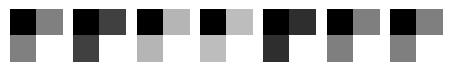

dataset shape: torch.Size([7, 2, 2]) 
data type: torch.float64


In [9]:
#- Load dataset -#

# Build my own dataset of images: gradient images
def apply_curve(x, curve):
    if curve == 'linear':
        return x
    elif curve == 'quadratic':
        return x ** 2
    elif curve == 'sqrt':
        return np.sqrt(x)
    elif curve == 'log':
        return np.log1p(x * 9) / np.log(10)  # scale [0,1] into [0,1] log space
    elif curve == 'exp':
        return (np.exp(x * 3) - 1) / (np.exp(3) - 1)  # normalized exponential
    elif curve == 'sigmoid':
        return 1 / (1 + np.exp(-10 * (x - 0.5)))  # smooth S-curve
    elif curve == 'sin':
        return 0.5 * (1 - np.cos(np.pi * x))  # smooth start and end
    else:
        raise ValueError(f"Unknown curve type: {curve}")

def create_gradients(total_pixels, directions=None, curves=None, width=None, height=None):
    if directions is None:
        directions = [
            'top_left_to_bottom_right'
        ]
    if curves is None:
        curves = ['linear', 'quadratic', 'sqrt', 'log', 'exp', 'sigmoid', 'sin']

    if width is None or height is None:
        for h in range(int(np.sqrt(total_pixels)), 0, -1):
            if total_pixels % h == 0:
                width, height = total_pixels // h, h
                break
    elif width * height != total_pixels:
        raise ValueError("Provided width and height do not match total number of pixels.")

    max_val = 255
    gradients = []

    i, j = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')

    # Precompute normalized coordinate matrices for all directions
    norm_maps = {
        'left_to_right': np.tile(np.linspace(0, 1, width), (height, 1)),
        'right_to_left': np.tile(np.linspace(1, 0, width), (height, 1)),
        'top_to_bottom': np.tile(np.linspace(0, 1, height)[:, np.newaxis], (1, width)),
        'bottom_to_top': np.tile(np.linspace(1, 0, height)[:, np.newaxis], (1, width)),
        'top_left_to_bottom_right': (i + j) / (width + height - 2),
        'bottom_right_to_top_left': ((height - 1 - i) + (width - 1 - j)) / (width + height - 2),
        'top_right_to_bottom_left': (i + (width - 1 - j)) / (width + height - 2),
        'bottom_left_to_top_right': ((height - 1 - i) + j) / (width + height - 2)
    }

    for direction in directions:
        if direction not in norm_maps:
            raise ValueError(f"Unknown direction: {direction}")
        base_map = norm_maps[direction]

        for curve in curves:
            # Apply curve to normalized map
            curved_map = apply_curve(base_map, curve)
            gradients.append(curved_map)

    image_array = np.array(gradients).reshape(-1, height, width)
    return image_array



# Create circuits file
def create_dataset_file(n_qubits, filename):
    image_array = create_gradients(n_qubits)
    np.save(filename, image_array)

    print("Dataset file created.")


# Load circuits from file
def load_dataset_file(filename):
    if config['embedding_options']['reset_dataset'] or not os.path.exists(filename):
        create_dataset_file(config['implementation_options']['n_qubits'], filename)

    X = np.load(filename)

    return X

X = load_dataset_file(config_path + "dataset.npy")
X = torch.as_tensor(X, device=device, dtype=dtype)


# Show dataset
for i in range(len(X)):
    plt.subplot(1,len(X)+1,i+1)
    plt.imshow(X[i].detach().cpu(), cmap="gray")
    plt.axis("off")
plt.show()
print("dataset shape:", X.shape, "\ndata type:", X.dtype)

In [10]:
#- Angle embedding -#

# Create real data sample circuit
def generate_real_circuit():
    n_qubits = config['implementation_options']['n_qubits']

    real_weights = ParameterVector('θ_r', n_qubits)
    qc = QuantumCircuit(n_qubits, name="Real circuit")
    param_index = 0

    for q in range(n_qubits):
        qc.ry(real_weights[param_index], q); param_index += 1

    return qc

In [11]:
#- Create quantum circuits -#

# Create generator
def generate_generator():
    n_qubits = config['implementation_options']['n_qubits']

    qc = real_amplitudes(n_qubits,
                        reps=3, # Number of layers
                        parameter_prefix='θ_g',
                        name='Generator')
    
    return qc.decompose()


# Create discriminator
def generate_discriminator():
    n_qubits = config['implementation_options']['n_qubits']

    qc = efficient_su2(n_qubits,
                      entanglement="reverse_linear",
                      reps=1, # Number of layers
                      parameter_prefix='θ_d',
                      name='Discriminator').decompose()


    param_index = qc.num_parameters

    for i in reversed(range(n_qubits - 1)):
        qc.cx(i, n_qubits - 1)

    #qc.rx(disc_weights[param_index], N_QUBITS-1); param_index += 1
    qc.ry(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    qc.rz(Parameter("θ_d["+str(param_index)+"]"), n_qubits-1); param_index += 1
    
    return qc


# Create circuits file
def create_circuits_file(filename):
    real_circuit = generate_real_circuit()
    generator_circuit = generate_generator()
    discriminator_circuit = generate_discriminator()

    with open(filename, 'wb') as fd:
        qpy.dump([real_circuit, generator_circuit, discriminator_circuit], fd)

    print("Circuits file created.")


# Load circuits from file
def load_circuits_file(filename):
    if config['data_management']['create_circuits'] or not os.path.exists(filename):
        create_circuits_file(filename)

    with open(filename, 'rb') as fd:
        circuits = qpy.load(fd)

    return circuits[0], circuits[1], circuits[2]
    
    
real_circuit, generator_circuit, discriminator_circuit = load_circuits_file(config_path + "circuits.qpy")

Circuits file created.


In [ ]:
#- Set up training quantum circuits -#
def generate_training_circuits(real_circuit, generator_circuit, discriminator_circuit):
    n_qubits = config['implementation_options']['n_qubits']

    # Connect real data and discriminator
    real_disc_circuit = QuantumCircuit(n_qubits)
    real_disc_circuit.compose(real_circuit, inplace=True)
    real_disc_circuit.compose(discriminator_circuit, inplace=True)

    # Connect real circuit to generator and discriminator for random input
    ran_gen_circuit = QuantumCircuit(n_qubits)
    if config['implementation_options']['random_input']: ran_gen_circuit.compose(real_circuit, inplace=True)
    ran_gen_circuit.compose(generator_circuit, inplace=True)

    # Connect generator and discriminator
    gen_disc_circuit = QuantumCircuit(n_qubits)
    gen_disc_circuit.compose(ran_gen_circuit, inplace=True)
    gen_disc_circuit.compose(discriminator_circuit, inplace=True)


    # Gradient computation method
    if config['implementation_options']['gradient_method'] == 'SPSA':
        gradient = SPSAEstimatorGradient(estimator=estimator, seed=config['implementation_options']['seed'])
    elif config['implementation_options']['gradient_method'] == 'REG':
        gradient = ReverseEstimatorGradient()
    else:
        gradient = ParamShiftEstimatorGradient(estimator=estimator)


    # Observables
    H1 = SparsePauliOp.from_list([("Z" + "I"*(n_qubits-1), 1.0)])

    obs_gen_eval_og = [SparsePauliOp.from_list([("I" * i + "Z" + "I" * (n_qubits - 1 - i), 1)]) for i in range(n_qubits)]


    # Transpilation
    real_disc_circuit_transpiled, gen_disc_circuit_transpiled = pm.run([real_disc_circuit, gen_disc_circuit])
    obs_real_disc = [H1.apply_layout(real_disc_circuit_transpiled.layout)]
    obs_gen_disc = [H1.apply_layout(gen_disc_circuit_transpiled.layout)]

    gen_eval_circuit_transpiled = eval_pm.run(ran_gen_circuit)
    obs_gen_eval = [ob.apply_layout(gen_eval_circuit_transpiled.layout) for ob in obs_gen_eval_og]


    N_DPARAMS = discriminator_circuit.num_parameters
    N_GPARAMS = generator_circuit.num_parameters

    # specify QNN to update generator parameters
    gen_qnn = EstimatorQNN(circuit=gen_disc_circuit_transpiled,
                        input_params=gen_disc_circuit_transpiled.parameters[:N_DPARAMS] + gen_disc_circuit_transpiled.parameters[(N_DPARAMS+N_GPARAMS):], # fixed parameters (discriminator + random parameters)
                        weight_params=gen_disc_circuit_transpiled.parameters[N_DPARAMS:(N_DPARAMS+N_GPARAMS)], # parameters to update (generator parameters)
                        estimator=estimator,
                        observables=obs_gen_disc,
                        gradient=gradient,
                        default_precision=training_precision,
                        #pass_manager=pm, # Not needed, already tranpsiled
                        #input_gradients=True # not needed even if i am using TorchConnector
                        )

    # specify QNN to update discriminator parameters regarding to fake data
    disc_fake_qnn = EstimatorQNN(circuit=gen_disc_circuit_transpiled,
                            input_params=gen_disc_circuit_transpiled.parameters[N_DPARAMS:], # fixed parameters (generator + random parameters)
                            weight_params=gen_disc_circuit_transpiled.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=obs_gen_disc,
                            gradient=gradient,
                            default_precision=training_precision,
                            #pass_manager=pm, # Not needed, already tranpsiled
                            #input_gradients=True # not needed even if i am using TorchConnector
                            )

    # specify QNN to update discriminator parameters regarding to real data
    disc_real_qnn = EstimatorQNN(circuit=real_disc_circuit_transpiled,
                            input_params=real_disc_circuit_transpiled.parameters[N_DPARAMS:], # fixed parameters (real data parameters)
                            weight_params=real_disc_circuit_transpiled.parameters[:N_DPARAMS], # parameters to update (discriminator parameters)
                            estimator=estimator,
                            observables=obs_real_disc,
                            gradient=gradient,
                            default_precision=training_precision,
                            #pass_manager=pm, # Not needed, already tranpsiled
                            #input_gradients=True # not needed even if i am using TorchConnector
                            )
    
    # specify Generator evaluator
    gen_eval_qnn = EstimatorQNN(circuit=gen_eval_circuit_transpiled,
                                input_params=gen_eval_circuit_transpiled.parameters[N_GPARAMS:], # fixed parameters (random parameters)
                                weight_params=gen_eval_circuit_transpiled.parameters[:N_GPARAMS], # parameters to update (generator parameters)
                                estimator=eval_estimator,
                                observables=obs_gen_eval,
                                gradient=gradient,
                                default_precision=eval_precision,
                                #pass_manager=pm, # Not needed, already tranpsiled
                                #input_gradients=False, # For evaluation
                                )
    

    return gen_qnn, disc_fake_qnn, disc_real_qnn, gen_eval_qnn

gen_qnn, disc_fake_qnn, disc_real_qnn, gen_eval_qnn = generate_training_circuits(real_circuit, generator_circuit, discriminator_circuit)

In [13]:
#f_loss = torch.nn.MSELoss(reduction="sum")
class FLoss(torch.nn.Module):
    def __init__(self):
        super(FLoss, self).__init__()

    def forward(self, x, label):
        loss = -x * label
        return loss.mean() # 'mean' for batches
    
f_loss = FLoss()


class JoinedDiscriminator(torch.nn.Module):
    def __init__(self, disc_real_qnn, disc_fake_qnn, initial_weights=None):
        super().__init__()
        self.model_dr = TorchConnector(disc_real_qnn)
        self.model_df = TorchConnector(disc_fake_qnn, initial_weights=initial_weights)
        self.tie_weights()

    def tie_weights(self):
        if 'weight' in self.model_dr._parameters:
            self.model_dr._parameters.pop('weight')
        if '_weights' in self.model_dr._parameters:
            self.model_dr._parameters.pop('_weights')
        self.model_dr._parameters['weight'] = self.model_df.weight
        self.model_dr._parameters['_weights'] = self.model_df.weight

    def parameters(self, recurse=True):
        return self.model_df.parameters(recurse=recurse)

    def named_parameters(self, prefix='', recurse=True, remove_duplicate=True):
        return self.model_df.named_parameters(
            prefix=prefix,
            recurse=recurse,
            remove_duplicate=remove_duplicate,
        )

    def state_dict(self, *args, **kwargs):
        return {
            'model_df_state': self.model_df.state_dict(*args, **kwargs),
        }

    def load_state_dict(self, state_dict, strict=True):
        result = self.model_df.load_state_dict(state_dict['model_df_state'], strict=strict)
        self.tie_weights()
        return result

    def _apply(self, fn):
        super()._apply(fn)
        self.tie_weights()
        return self

    def forward(self, real_input, fake_input):
        real_output = self.model_dr(real_input)
        fake_output = self.model_df(fake_input)
        return real_output, fake_output


In [14]:
#- Restore parameters and model states -#

# Reset all data training
def create_training_data_file(n_gen_params, n_disc_params, filename):
    np.random.seed(config['implementation_options']['seed'])
    torch.manual_seed(config['implementation_options']['seed'])

    init_gen_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_gen_params,)) * 0.1 # Start from near 0 parameters to mitigate drastic changes at the start
    init_disc_params = np.random.uniform(low=-np.pi, high=np.pi, size=(n_disc_params,)) * 0.1

    gen_params = torch.tensor(init_gen_params, requires_grad=True, dtype=dtype)
    disc_params = torch.tensor(init_disc_params, requires_grad=True, dtype=dtype)

    params = {
        'init_gen_params': init_gen_params,
        'init_disc_params': init_disc_params,
        'gen_params': gen_params,
        'disc_params': disc_params,
        'best_gen_params': init_gen_params,
        'current_epoch': 0,
        "metrics": {
            "gloss": {},
            "dloss": {},
            "eval": {},
            'times': {},
        },
        'np_random_state': np.random.get_state(),
        'torch_rng_state': torch.get_rng_state()
    }

    model_g = TorchConnector(gen_qnn, initial_weights=init_gen_params)
    model_d = JoinedDiscriminator(disc_real_qnn, disc_fake_qnn, initial_weights=init_disc_params)
    eval_g = TorchConnector(gen_eval_qnn)

    if 'weight' in eval_g._parameters:
        eval_g._parameters.pop('weight')
    if '_weights' in eval_g._parameters:
        eval_g._parameters.pop('_weights')
    eval_g._parameters['weight'] = model_g.weight
    eval_g._parameters['_weights'] = model_g.weight

    model_g.train() 
    model_d.train()
    eval_g.eval()

    optimizer_g = torch.optim.Adam(model_g.parameters(), lr=0.005)
    optimizer_d = torch.optim.Adam(model_d.parameters(), lr=0.005)

    params['model_g_state'] = model_g.state_dict()
    params['model_d_state'] = model_d.state_dict()
    params['eval_g_state'] = eval_g.state_dict()
    

    params['optimizer_g_state'] = optimizer_g.state_dict()
    params['optimizer_d_state'] = optimizer_d.state_dict()

    torch.save(params, filename)

    print("Training data file created.")


# Load parameters and training states from file
def load_training_data_file(filename):
    if config['data_management']['reset_training_data'] or not os.path.exists(filename):
        create_training_data_file(generator_circuit.num_parameters, discriminator_circuit.num_parameters, filename)

    params = torch.load(filename, weights_only=False, map_location=device)

    return params


params = load_training_data_file(config_path + "training_data.pth")

np.random.set_state(params['np_random_state'])
torch.set_rng_state(params['torch_rng_state'])

gen_params = params['gen_params']
disc_params = params['disc_params']

current_epoch = params['current_epoch']
epoch = current_epoch - 1
gloss = params['metrics']['gloss']
gen_loss = list(gloss.values())[-1] if gloss else None
dloss = params['metrics']['dloss']
disc_loss = list(dloss.values())[-1] if dloss else None
eval = params['metrics']['eval']
min_eval = np.min(list(eval.values())) if (eval) else float('inf')
best_gen_params = params['best_gen_params']
times = params['metrics']['times']


model_g = TorchConnector(gen_qnn)    
model_d = JoinedDiscriminator(disc_real_qnn, disc_fake_qnn)
eval_g = TorchConnector(gen_eval_qnn)

model_g.load_state_dict(params['model_g_state'])
model_d.load_state_dict(params['model_d_state'])
eval_g.load_state_dict(params['eval_g_state'])

model_g.to(device)
model_d.to(device)
eval_g.to(device)

if 'weight' in eval_g._parameters:
    eval_g._parameters.pop('weight')
if '_weights' in eval_g._parameters:
    eval_g._parameters.pop('_weights')
eval_g._parameters['weight'] = model_g.weight
eval_g._parameters['_weights'] = model_g.weight

optimizer_g = torch.optim.Adam(model_g.parameters())
optimizer_d = torch.optim.Adam(model_d.parameters())


optimizer_g.load_state_dict(params['optimizer_g_state'])
optimizer_d.load_state_dict(params['optimizer_d_state'])

Training data file created.


In [15]:
#- Manage training interruption -#

# Class to manage training interruption
class Interrupter:
    def __init__(self):
        self.kill_now = False
        self.interrupt_count = 0

        # Intercept the Ctrl+C signal
        signal.signal(signal.SIGINT, self.handle_signal)
        # Intercept the termination signal (useful for Docker/systems)
        #signal.signal(signal.SIGTERM, self.handle_signal)

    def handle_signal(self, signum, frame):
        self.interrupt_count += 1
        
        if self.interrupt_count == 1:
            # First Press: Enable graceful exit
            self.kill_now = True
            print("\nInterrupter: Termination signal received. The loop will stop after the current iteration. (Press Ctrl+C again to force quit)")
        
        elif self.interrupt_count >= 2:
            # Second Press: Force quit immediately
            print("\nInterrupter: [!] Force quit triggered! Terminating immediately.")
            # Restore default signal handler to avoid recursion
            signal.signal(signal.SIGINT, signal.SIG_DFL)
            # Raise the exception to stop execution right here
            raise KeyboardInterrupt

In [ ]:
#- Evualuation method -#

# Evaluate specific gradient (top-left to bottom-right) for small images
img_h, img_w = X.shape[1:3]
def evaluate(gen_dists, targets=None):
    batch = gen_dists.reshape(-1, img_h, img_w)

    h_diff = batch[:, :, 1:] - batch[:, :, :-1]
    v_diff = batch[:, 1:, :] - batch[:, :-1, :]

    h_penalty = (-h_diff.clamp(max=0)).mean()
    v_penalty = (-v_diff.clamp(max=0)).mean()

    penalty = 0.5 * (h_penalty + v_penalty)
    return penalty.item()


In [17]:
#- Batch parallelization -#

N_RPARAMS = gen_eval_qnn.num_inputs

# Create random input
def generate_random_input(batch_size, num_params):
    return 2 * torch.pi * torch.rand(
        batch_size,
        num_params,
        device=device,
        dtype=dtype,
    ) * config['embedding_options']['randomness']


# Get real data input
def generate_real_input(batch_size):
    data_indexes = torch.randint(
        low=0,
        high=X.shape[0],
        size=(batch_size,),
        device=device,
    )

    return X[data_indexes].reshape(batch_size, -1)

# Generate fake input for discriminator
def generate_fake_disc_input(batch_size):
    gen_params = torch.nn.utils.parameters_to_vector(model_g.parameters()).detach() #gen_params = optimizer_g.param_groups[0]['params'][0].detach()

    gen_batch = gen_params.reshape(1, -1).expand(batch_size, -1)
    random_batch = generate_random_input(batch_size, N_RPARAMS)

    return torch.cat([gen_batch, random_batch], dim=1)

# Generate input for generator
def generate_gen_input(batch_size):
    disc_params = torch.nn.utils.parameters_to_vector(model_d.parameters()).detach() #disc_params = optimizer_d.param_groups[0]['params'][0].detach()

    disc_batch = disc_params.reshape(1, -1).expand(batch_size, -1)
    random_batch = generate_random_input(batch_size, N_RPARAMS)

    return torch.cat([disc_batch, random_batch], dim=1)


# Evaluate batch of generated samples with real samples
def batch_evaluation(batch_size):
    with torch.no_grad():

        # Get fake samples
        random_input = generate_random_input(batch_size, N_RPARAMS)
        fake_outputs = eval_g(random_input)

        # Get real samples
        #targets = generate_real_input(batch_size)

        current_eval = evaluate(fake_outputs)

    return current_eval


In [18]:
#- Forward and backward pass -#

batch_size = config['embedding_options']['batch_size']


# Discriminator pass
def disc_pass():
    optimizer_d.zero_grad()

    # Calculate discriminator gradient with real and generated data
    real_inputs = generate_real_input(batch_size)
    fake_inputs = generate_fake_disc_input(batch_size)
    real_output, fake_output = model_d(real_inputs, fake_inputs)
    real_loss = f_loss(real_output, torch.ones_like(real_output)) # 1-> Real guess (correct)
    fake_loss = f_loss(fake_output, -torch.ones_like(fake_output)) # -1-> Fake guess (correct)
    loss = real_loss + fake_loss
    loss.backward()

    optimizer_d.step()

    # Calculate discriminator cost
    disc_loss = (real_loss.item() + fake_loss.item() -2)/4

    return disc_loss

# Generator pass
def gen_pass():
    optimizer_g.zero_grad()

    # Calculate generator gradient
    gen_inputs = generate_gen_input(batch_size)
    gen_output = model_g(gen_inputs)
    gen_loss = f_loss(gen_output, torch.ones_like(gen_output)) # 1-> Real guess (decieved)
    gen_loss.backward()  # Backward pass

    optimizer_g.step()

    # Calculate generator cost
    gen_loss = (gen_loss.item() -1)/2
    
    return gen_loss

# Copy parameters
def copy_params():
    return torch.nn.utils.parameters_to_vector(model_g.parameters()).detach().cpu().numpy().copy()

In [19]:
#- Training -#

D_STEPS = config['training_parameters']['disc_iterations']
G_STEPS = config['training_parameters']['gen_iterations']

interrupter = Interrupter()

if config['training_parameters']['print_progress_iterations']:
    TABLE_HEADERS = "Epoch | Generator cost | Discriminator cost | Eval | Best eval | Time |"
    print(TABLE_HEADERS)

prev_times = 0
start_time = time.time()

#--- Training loop ---#
try: # In case of interruption
    for epoch in range(current_epoch, config['training_parameters']['max_iterations']+1):

        #--- Quantum discriminator parameter updates ---#
        for disc_train_step in range(D_STEPS):
            disc_loss = disc_pass()
            dloss[epoch] = disc_loss


        #--- Quantum generator parameter updates ---#
        for gen_train_step in range(G_STEPS):
            gen_loss = gen_pass()
            gloss[epoch] = gen_loss


        #--- Track Eval and save best performing generator weights ---#
        current_eval = batch_evaluation(batch_size*2)
        eval[epoch] = current_eval
        if min_eval > current_eval:
            min_eval = current_eval
            best_gen_params = copy_params() # New best
        

        # Calculate time
        cur_time = (time.time() - start_time)
        times[epoch] = cur_time
        start_time = time.time()


        #--- Print progress ---#
        if config['training_parameters']['print_progress_iterations'] and (epoch % config['training_parameters']['print_progress_iterations'] == 0):
            now_times = sum(times.values())
            for header, val in zip(TABLE_HEADERS.split('|'),
                                (epoch, gen_loss, disc_loss, current_eval, min_eval, now_times - prev_times)):
                print(f"{val:.3g} ".rjust(len(header)), end="|")
            print()

            prev_times = now_times


        # In case of interruption
        if interrupter.kill_now:
            print("Interrupter: Graceful exit triggered. Breaking loop.")
            break
            
#--- Save parameters and optimizer states data ---#
finally:
    params = {
        'init_gen_params': params['init_gen_params'],
        'init_disc_params': params['init_disc_params'],
        'best_gen_params': best_gen_params,
        'gen_params': torch.nn.utils.parameters_to_vector(model_g.parameters()).detach().cpu(),
        'disc_params': torch.nn.utils.parameters_to_vector(model_d.parameters()).detach().cpu(),
        'current_epoch': epoch+1,
        "metrics": {
            "gloss": gloss,
            "dloss": dloss,
            "eval": eval,
            'times': times,
        },
        'np_random_state': np.random.get_state(),
        'torch_rng_state': torch.get_rng_state(),
        'optimizer_g_state': optimizer_g.state_dict(),
        'optimizer_d_state': optimizer_d.state_dict(),
    }

    params['model_g_state'] = model_g.state_dict()
    params['model_d_state'] = model_d.state_dict()
    params['eval_g_state'] = eval_g.state_dict()
    
    torch.save(params, config_path + "training_data.pth")
    
    if config['implementation_options']['execution_type'] == "real":
        session.close()

    eval_data = list(eval.values()) if eval else [0]
    print("Training complete:", "\n   Data path:", config_path, "\n   Best eval:", np.min(eval_data), "in epoch", np.argmin(eval_data), "\n   Improvement:", eval_data[0]-np.min(eval_data), "\n   Total time:", sum(times.values()))

Epoch | Generator cost | Discriminator cost | Eval | Best eval | Time |
Training complete: 
   Data path: ../data/test/qgan_TorchConnector_ang-q4-noisy-CPU-REG-randomTrue-seed0/ 
   Best eval: 0 in epoch 0 
   Improvement: 0 
   Total time: 0


QiskitMachineLearningError: 'Estimator job failed. Maximum allowed dimension exceeded'